## Problems:
Section 1
Introduction
What is text summarization?

⸻

Section 2
Extractive vs Abstractive

<br>Explain:<br><br>
Extractive<br>
TextRank<br>
LexRank<br><br>

Abstractive<br>
BART<br>
PEGASUS<br>
T5<br>

⸻

Section 3
Transformers
Learn:
* Attention
* Encoder
* Decoder
* Self-attention
* Beam Search

⸻

Section 4
Long Context Problem
Learn:
Why BART struggles with:
10000+ word transcripts

⸻

Section 5
Evaluation Metrics
ROUGE
ROUGE-L
Human Evaluation

⸻

Deliverable
Notebook with:
20-30 pages worth of markdown + notes

## Text Summarization

Automatic text summarization (or document summarization) is a natural language processing (NLP) method that condenses information from one or more input text documents into an original output text. How much of the input text appears in the output is debated—some definitions state only 10%, others 50%.1 Text summarization algorithms often use deep learning architectures—specifically, transformers—to parse documents and generate text summaries.

There are two primary types of text summarization techniques:

Extractive Summarization<br>
Abstractive Summarization


#####   <b> Extractive Summarization<br></b>
selects key parts from the passasge. no new content created. orignal meaning preserved.<br>
TestRank algo used widely<br>
By ranking sentences based on their relevance and importance, it can generate a concise summary


Test rank implemented in spaCy lib no new parts generated

spacy lib<br>
Core Features<br>
Tokenization:      &emsp; Segmenting text into words, punctuation, and symbols.
<br>Named Entity Recognition (NER):      &emsp;   Identifying and labeling real-world objects like persons, organizations, or locations.<br>Part-of-Speech (POS) Tagging:      &emsp;   Assigning grammatical roles to words (e.g., noun, verb).<br>
Dependency Parsing:        &emsp;  Analyzing syntactic relationships between words in a sentence.
<br>Lemmatization:  &emsp;    Reducing words to their base or dictionary form (e.g., "running" to "run").
<br>Word Vectors:    &emsp;    Using pre-trained word embeddings to measure semantic similarity between words.

#### en_core_web_lg is a large, pre-trained English Natural Language Processing (NLP) pipeline provided by spaCy

In [1]:
import spacy
import pytextrank

nlp = spacy.load("en_core_web_lg")
nlp.add_pipe("textrank")

example_text = """Deep learning (also known as deep structured learning) is part of a 
broader family of machine learning methods based on artificial neural networks with 
representation learning. Learning can be supervised, semi-supervised or unsupervised. 
Deep-learning architectures such as deep neural networks, deep belief networks, deep reinforcement learning, 
recurrent neural networks and convolutional neural networks have been applied to
fields including computer vision, speech recognition, natural language processing, 
machine translation, bioinformatics, drug design, medical image analysis, material
inspection and board game programs, where they have produced results comparable to 
and in some cases surpassing human expert performance. Artificial neural networks
(ANNs) were inspired by information processing and distributed communication nodes
in biological systems. ANNs have various differences from biological brains. Specifically, 
neural networks tend to be static and symbolic, while the biological brain of most living organisms
is dynamic (plastic) and analogue. The adjective "deep" in deep learning refers to the use of multiple
layers in the network. Early work showed that a linear perceptron cannot be a universal classifier, 
but that a network with a nonpolynomial activation function with one hidden layer of unbounded width can.
Deep learning is a modern variation which is concerned with an unbounded number of layers of bounded size, 
which permits practical application and optimized implementation, while retaining theoretical universality 
under mild conditions. In deep learning the layers are also permitted to be heterogeneous and to deviate widely 
from biologically informed connectionist models, for the sake of efficiency, trainability and understandability, 
whence the structured part."""
print('Original Document Size:',len(example_text))
doc = nlp(example_text)

for sent in doc._.textrank.summary(limit_phrases=2, limit_sentences=2):# two phrases and sentences extracted
    print(sent)
    print('Summary Length:',len(sent))

/Users/par_04/code_playground/projects/TranscriptMind/.tsmind/lib/python3.11/site-packages
Original Document Size: 1820
Deep-learning architectures such as deep neural networks, deep belief networks, deep reinforcement learning, 
recurrent neural networks and convolutional neural networks have been applied to
fields including computer vision, speech recognition, natural language processing, 
machine translation, bioinformatics, drug design, medical image analysis, material
inspection and board game programs, where they have produced results comparable to 
and in some cases surpassing human expert performance.
Summary Length: 81
Specifically, 
neural networks tend to be static and symbolic, while the biological brain of most living organisms
is dynamic (plastic) and analogue.
Summary Length: 29


##### <b> Abstractive Summarization</b><br>


Abstractive summarization generates entirely new sentences to convey key ideas from the original text. Unlike extractive summarization, which selects and rearranges sentences from the original content, abstractive methods rephrase information in a more concise and coherent manner, often using new vocabulary that wasn't present in the original.

earlier RNN used now Transformers

Pegasus is a top notch transformer model used for text summarization<br>
uses a unique pre-training strategy where critical sentences are masked during trainingThe model is then tasked with generating these hidden sentences, <br><br> Then during inferernce, it to create more accurate and coherent summaries.

In [2]:
from transformers import pipeline
from transformers import PegasusForConditionalGeneration, PegasusTokenizer

# Pick model
model_name = "google/pegasus-xsum"
# Load pretrained tokenizer
pegasus_tokenizer = PegasusTokenizer.from_pretrained(model_name)

example_text = """
Deep learning (also known as deep structured learning) is part of a broader family of machine learning
methods based on artificial neural networks with representation learning. 
Learning can be supervised, semi-supervised or unsupervised. Deep-learning architectures such as 
deep neural networks, deep belief networks, deep reinforcement learning, 
recurrent neural networks and convolutional neural networks have been applied to 
fields including computer vision, speech recognition, natural language processing,
machine translation, bioinformatics, drug design, medical image analysis, 
material inspection and board game programs, where they have produced results 
comparable to and in some cases surpassing human expert performance. 
Artificial neural networks (ANNs) were inspired by information processing and 
distributed communication nodes in biological systems. ANNs have various differences 
from biological brains. Specifically, neural networks tend to be static and symbolic,
while the biological brain of most living organisms is dynamic (plastic) and analogue.
The adjective "deep" in deep learning refers to the use of multiple layers in the network.
Early work showed that a linear perceptron cannot be a universal classifier, 
but that a network with a nonpolynomial activation function with one hidden layer of 
unbounded width can. Deep learning is a modern variation which is concerned with an 
unbounded number of layers of bounded size, which permits practical application and 
optimized implementation, while retaining theoretical universality under mild conditions. 
In deep learning the layers are also permitted to be heterogeneous and to deviate widely 
from biologically informed connectionist models, for the sake of efficiency, trainability 
and understandability, whence the structured part."""

print('Original Document Size:',len(example_text))
# Define PEGASUS model
pegasus_model = PegasusForConditionalGeneration.from_pretrained(model_name)
# Create tokens
tokens = pegasus_tokenizer(example_text, truncation=True, padding="longest", return_tensors="pt")

# Generate the summary
encoded_summary = pegasus_model.generate(**tokens)

# Decode the summarized text
decoded_summary = pegasus_tokenizer.decode(encoded_summary[0], skip_special_tokens=True)

# Print the summary
print('Decoded Summary :',decoded_summary)

summarizer = pipeline(
    "summarization", 
    model=model_name, 
    tokenizer=pegasus_tokenizer, 
    framework="pt"
)

summary = summarizer(example_text, min_length=30, max_length=150)
summary[0]["summary_text"]

/Users/par_04/code_playground/projects/TranscriptMind/.tsmind/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original Document Size: 1825


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Decoded Summary : Deep learning is a branch of computer science that deals with the study and training of machine learning.


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use mps:0


'Deep learning is a branch of computer science that deals with the study and training of machine learning systems, such as deep-learning algorithms, on a large scale.'

In [3]:
import transformers
print(transformers.__version__)

4.57.1


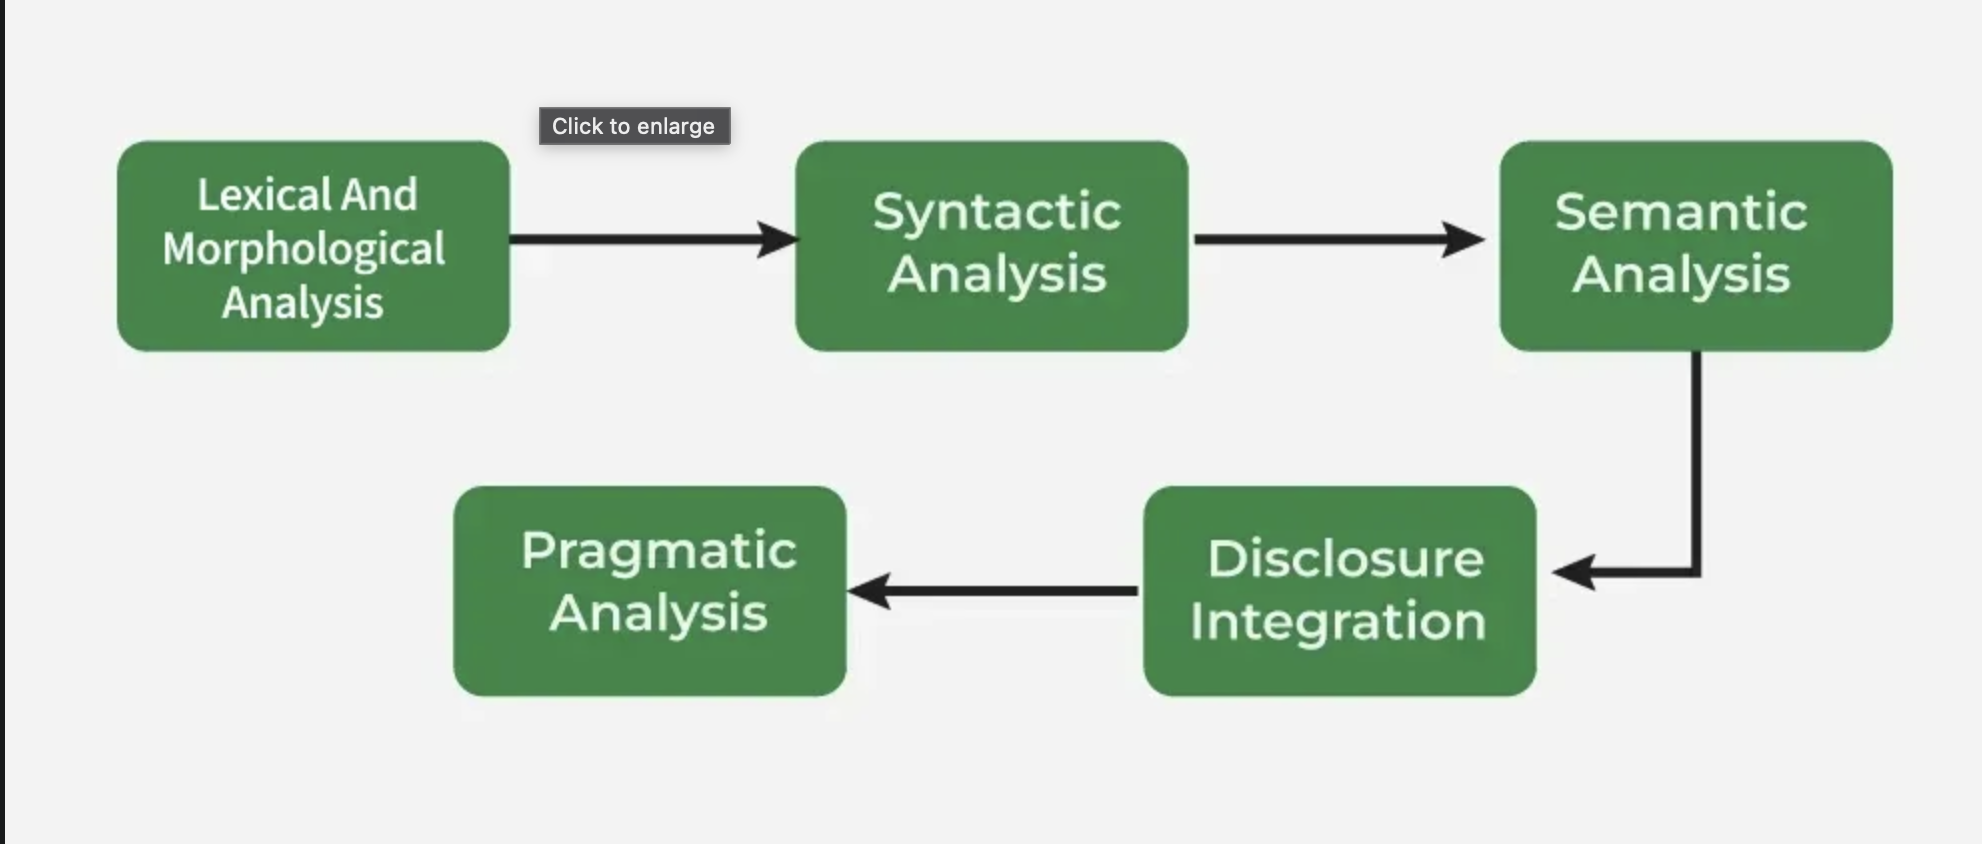

### Lexical analysis : Tokenize
<br>focuses on identifying and processing words by breaking text into meaningful units called tokens.<br>
Sentence: "I am reading a book."

Tokenization: ["I", "am", "reading", "a", "book"]

### Morphological Analysis : boil down

<br>Morphological analysis studies the internal structure of words using morphemes, the smallest units of meaning.

<br>Stemming reduces words to their root form like "running" to "run".
<br>Lemmatization converts words to their base or dictionary form considering the context like "better" becomes "good".
<br>Helps understand word formation and structure
<br>Improves accuracy in parsing, translation and tagging tasks
<br>Supports advanced NLP applications through word normalization

 It identifies relationships between words and creates a parse tree representing the sentence structure.

### Syntactic Analysis (Parsing) : parse tree<br>
<b>It identifies relationships between words and creates a parse tree representing the sentence structure</b><br>
POS Tagging: Assigns grammatical categories such as noun, verb, and adjective<br>
Ambiguity Resolution: Handles words with multiple meanings based on context


### Semantic Analysis:Meaning <br>
focuses on understanding the meaning of words and sentences<br>
Named Entity Recognition (NER): Identifies entities such as people, locations, organizations and dates<br>
Word Sense Disambiguation (WSD): Determines the correct meaning of words with multiple meanings based on context



 ### Discourse Integration: Multiline relation<br>
Discourse Integration focuses on understanding how multiple sentences connect within a larger context
<br>Anaphora Resolution: Identifies references such as pronouns and links them to the correct subject
<br>Contextual References: Understands words or phrases based on surrounding context

## Pragmatic Analysis: Intention and Purpose <br>
Pragmatic Analysis focuses on understanding the intended meaning of words and sentences by considering context, tone, and speaker intention beyond the literal meaning.<br>
Understanding Intentions: Identifies the actual purpose behind statements or questions<br>
Figurative Meaning: Interprets non literal expressions such as idioms and metaphors


# NLP steps

There are 7 basic steps by which a machine can process natural language, which is as follows<br>

Segmentation - It is a process of dividing complex sentences into smaller sentences.<br>
Tokenizing - It is the process of breaking simple sentences into words.<br>
Stop words - The words that do not play an important role in generating a meaning to the sentence such as and, the, is, etc. are removed from the sentences which are known as stop words.<br>
Stemming - It is the process of teaching a basic set of data in sentences which probably means the same. Hence creating awareness in our system.<br>
Lemmatization - The addition of emotions and moods to words so that a machine can comprehend the emotional relation of a sentence to a human and hence generate a reasonable response is called lemmatization.<br>
Speech Tagging - The process of teaching basic grammar terms such as nouns, verbs, prepositions, etc. to a machine and tagging every word in a sentence as that grammatical term is called speech tagging.<br>
Named entity Tagging - To understand the important noun referred to in the document which are popular humans like actors, etc, and tagging them is known as named entity tagging.<br>

# NLP TOOLS


Tools Used For NLP
1. IBM Watson 

IBM Watson NLP  is a tool that has major capabilities which allow you to detect, and extract keywords, emotions, entities, and various other factors.

2. Core NLP 

It is a powerful and quick annotator for discretionary text that is widely used in production. It is largely Java based.

3. Spacy

It is a pre-trained statistical model as well as a word vector. It is a python compatible language. It enables tokenization for more than 49 languages.

4. AllenNLP

It is a sophisticated prototype tool with text-processing features. This tool, when compared to Spacy is not that much used in terms of manufacturing but is used vividly in terms of research analysis.

5. NTLK

It offers a complete set of programs and modules to analyze data in the form of statistical and symbolic analysis using Python. It is one of the most important tools in NLP.

6. GPT- 3 

A very trendy tool created by open AI that helps auto-completing and auto-generating the sentence on its own which is vividly used in the aspect of text prediction.

7. Monkey Learn

It is a simple tool that aids in the extraction of important insights from our data and helps in text analysis such as keyword analysis, etc.

8. Text blob

It is a tool that helps in analyzing segmentation, tokenization, word paraphrasing, translation, speech tagging, etc.

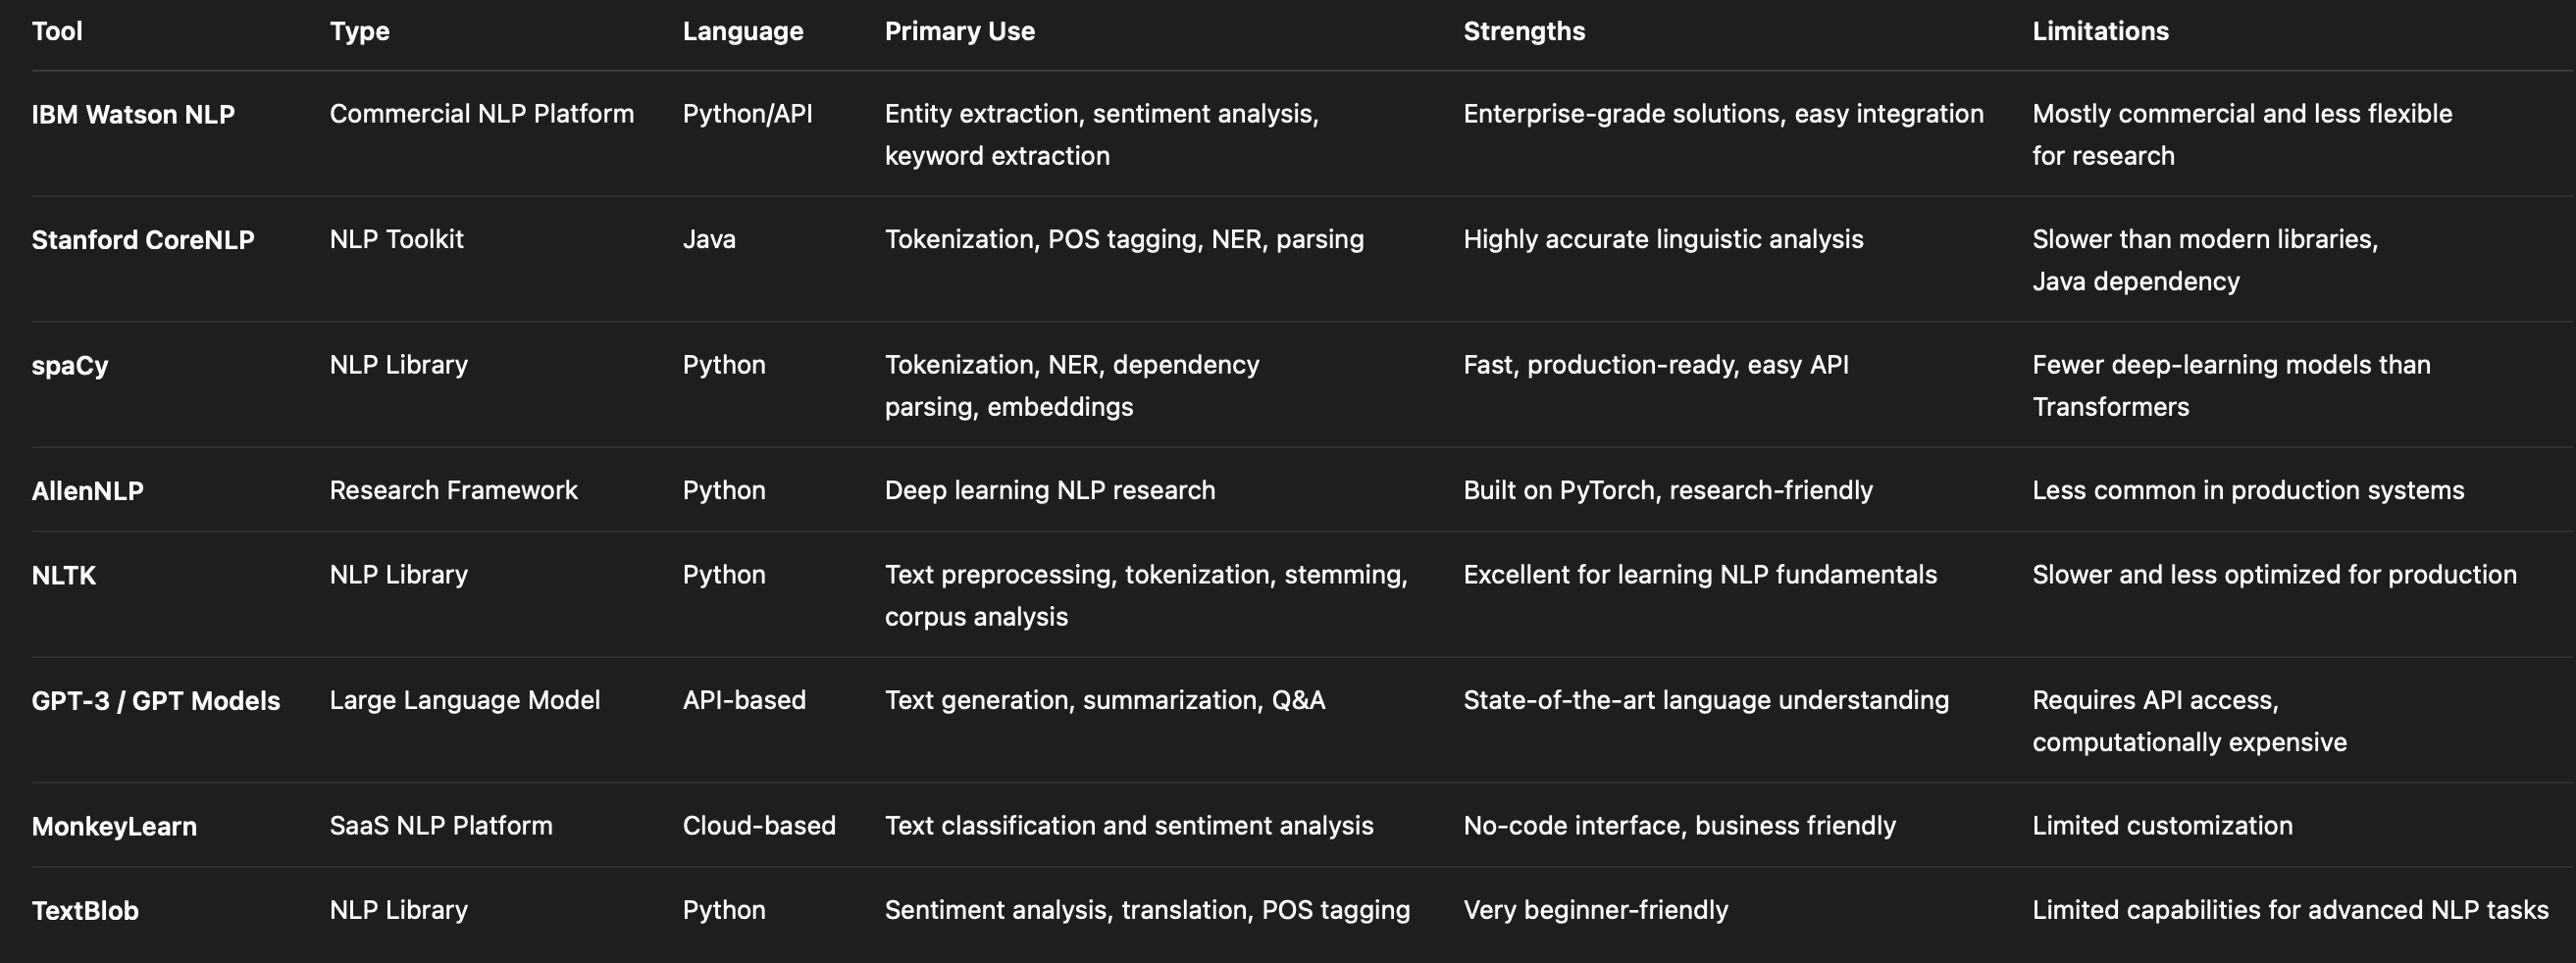

# TEXTRANK<BR>

graph based summarizer algo <br>
keyword extraction<br>
unsupervised: hence works well even if low training data availible<br>
words: co-occurance<br>
sentenss: similarity
words and sentces are nodes<br>
node size = importance<br>
algo works on : keyword extraction and sentence extraction<br>
global info taken recursively from the graph and imp computed<br>
#### applications:<br>
    1.sentence extraction: summarization   
    2.keyword extraction
<br>
summariztion<br>
Words as Nodes: Every unique word becomes a point (node) in a network.Context as Links: Connections (links) are drawn between words that appear next to each other within a small moving window (e.g., 2 to 5 words apart).Voting Power: Words linked to many other words receive higher importance scores.Keyword Extraction: The highest-scoring words are selected as the main keywords of the sentence or document.<br><br>
TEXT ->senteces -> cosine similarity over TF-IDF(statistical measure of the importance of the word) ->Together, they form a vector representation of each sentence, where each dimension reflects a word’s weighted importance. These vectors are used to compute semantic similarity between sentences — a key step in TextRank..<br><br>
    1. Construct a graph with sentences as nodes and similarity as edge weights.<br>
    2. Run PageRank to score each sentence..<br>
    3. Select top-ranked sentences as the summary..<br>
The intuition is that sentences that are similar to many others are likely to be central to the document. Graph-based methods like TextRank thus provide an elegant way to identify this centrality.

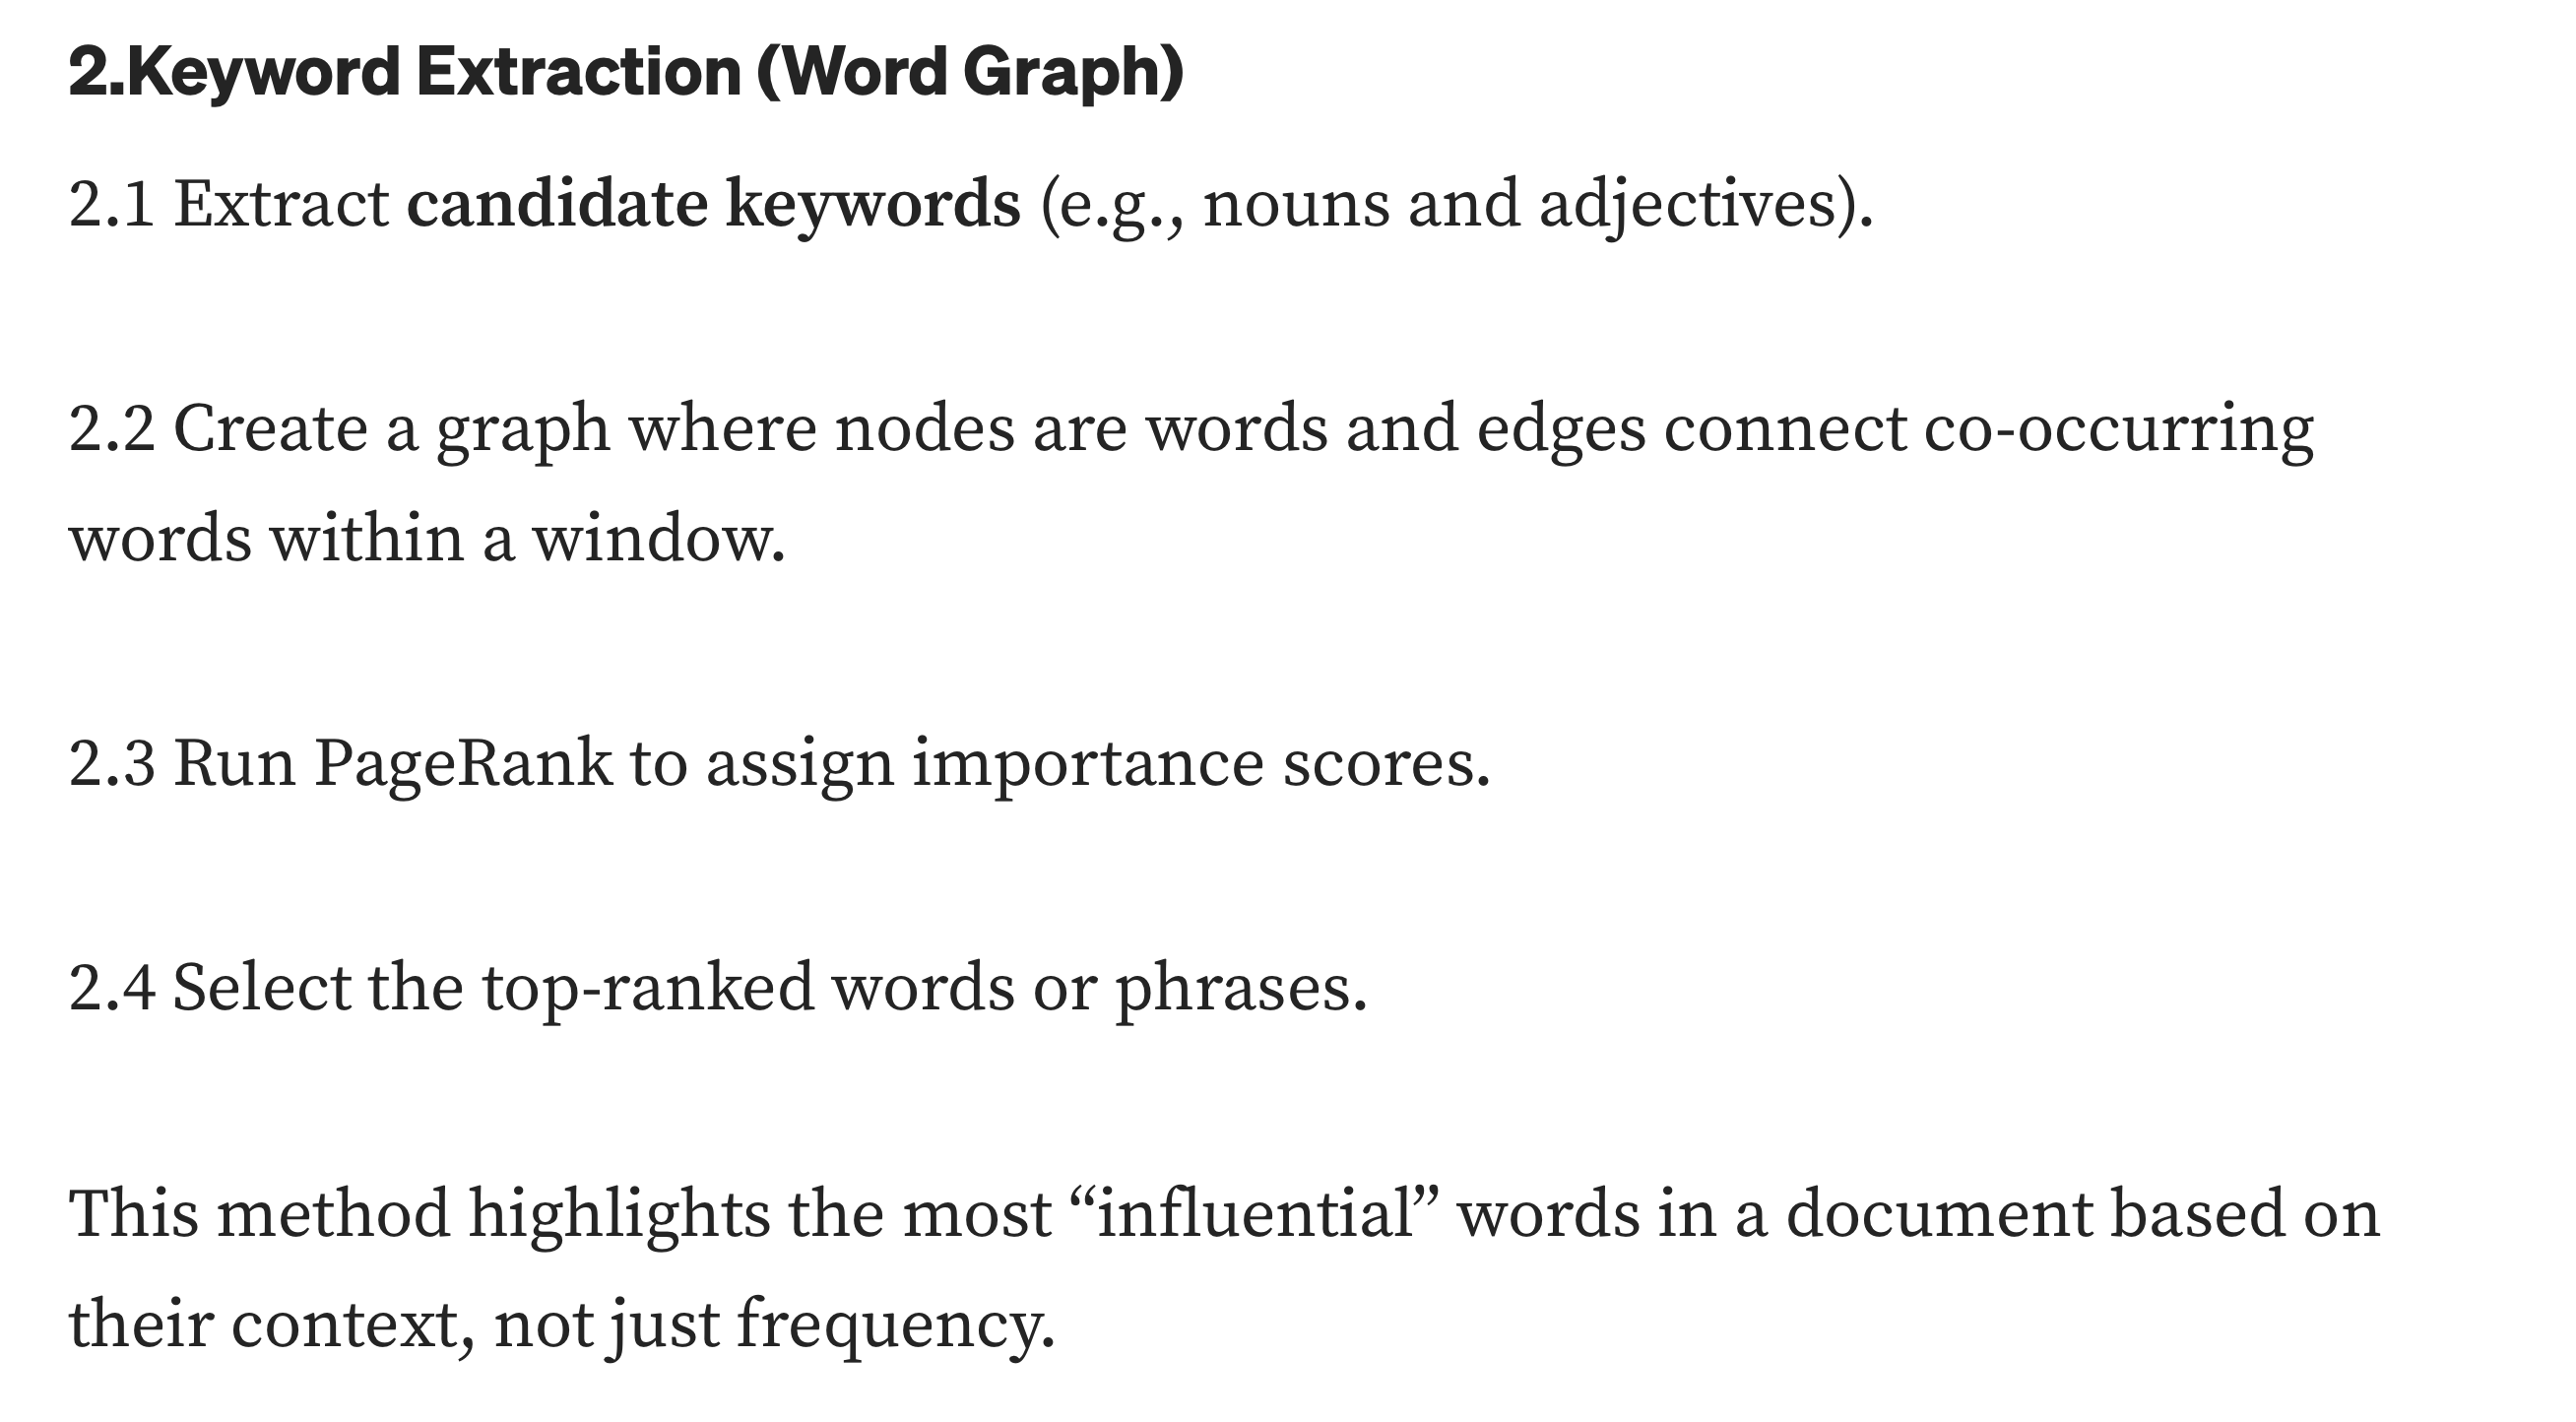


In [5]:
## IMPLEMENTAION TO BE ADDED final

# LEXRANK


# BART


# PEGASUS

# T5